In [1]:
import pandas as pd

In [5]:
measurements = pd.read_csv('../data/test_measure.csv')

In [4]:
subjects = pd.read_csv('../data/subject-info.csv')

array([[<Axes: xlabel='time'>],
       [<Axes: xlabel='time'>],
       [<Axes: xlabel='time'>],
       [<Axes: xlabel='time'>]], dtype=object)

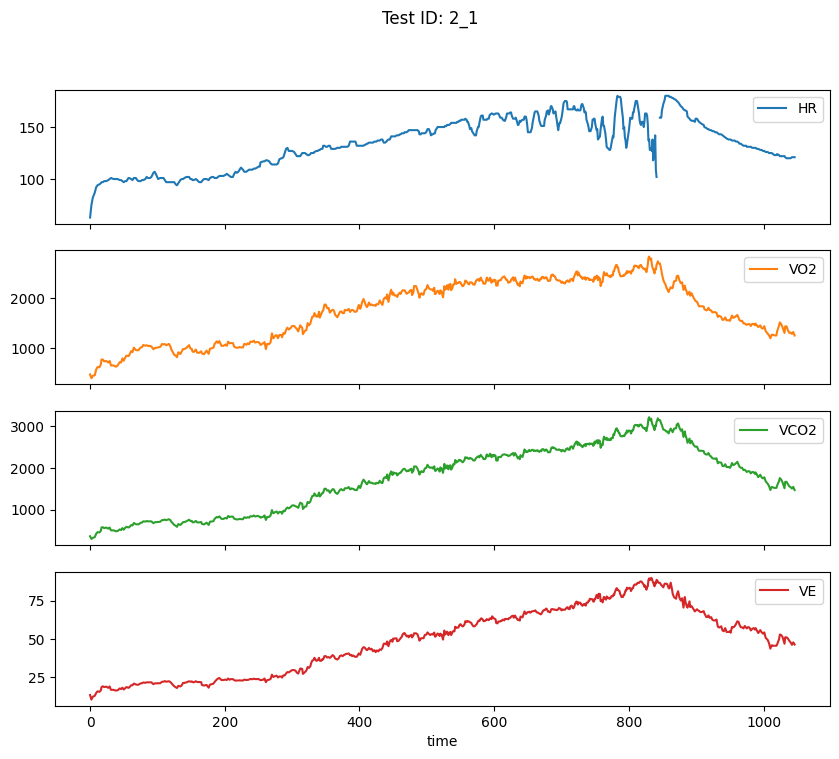

In [11]:
test_id = measurements['ID_test'].iloc[0]

one_test = measurements[measurements['ID_test'] == test_id]

measurements[measurements['ID_test'] == test_id]

one_test.plot(x='time', y = ['HR', 'VO2', 'VCO2', 'VE'], subplots=True, layout=(4,1), figsize=(10,8), title=f'Test ID: {test_id}')

In [14]:
peak_index = one_test['VO2'].idxmax()
peak_index
one_test.loc[peak_index]

time          830
Speed        16.0
HR          138.0
VO2        2833.0
VCO2       3220.0
RR             56
VE           89.5
ID_test       2_1
ID              2
Name: 483, dtype: object

In [21]:
peak_time = one_test.loc[peak_index, 'time']
peak_window = one_test[(one_test['time'] >= peak_time - 30) & (one_test['time'] <= peak_time)]
peak_window['VO2'].mean()

np.float64(2616.0714285714284)

In [28]:
one_test = one_test.copy()

one_test['Time Delta'] = pd.to_timedelta(one_test['time'], unit='s')

one_test['VO2 Rolling Mean'] = one_test.rolling('30s', on='Time Delta')['VO2'].mean()

one_test['VO2 Rolling Mean'].max()

np.float64(2657.1923076923076)